## Часть 1. Исследование многомерного нормального распределения

In [53]:
import numpy as np
import matplotlib.pyplot as plt
# Параметры
M = 500
sigma1 = 0.3
sigma2 = 0.8
alpha_deg = 30
alpha_rad = np.radians(alpha_deg)

# Генерация двух независимых векторов
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)

# Исходный массив точек до поворота
X_init = np.column_stack([x1, x2])

# Матрица поворота R
R = np.array([
    [np.cos(alpha_rad), -np.sin(alpha_rad)],
    [np.sin(alpha_rad),  np.cos(alpha_rad)]
])

# Применение поворота к точкам
X = X_init @ R.T

# Выборочная матрица ковариации
C_sample = np.cov(X.T)
print("Выборочная матрица ковариации:\n", C_sample)

# Теоретическая матрица ковариации: C_teor = R * diag(sigma1^2, sigma2^2) * R^T
C_teor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T
print("Теоретическая матрица ковариации:\n", C_teor)


Выборочная матрица ковариации:
 [[ 0.21736373 -0.22290919]
 [-0.22290919  0.47946726]]
Теоретическая матрица ковариации:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


In [54]:
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print("Автопроверка пройдена")

Автопроверка пройдена


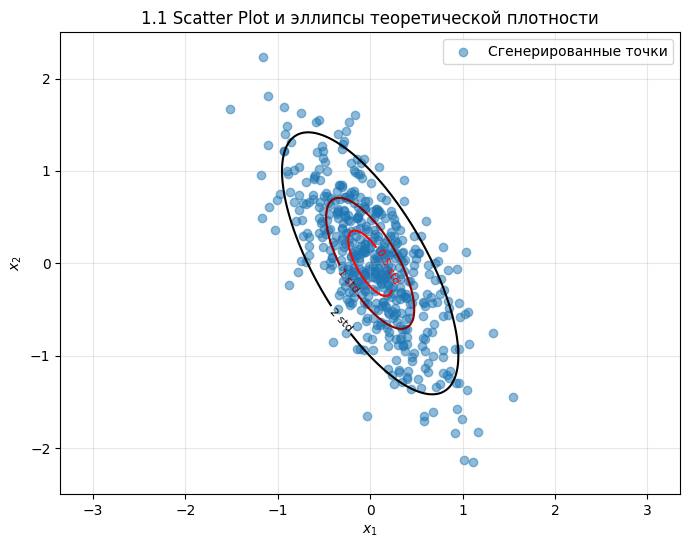

In [55]:
# Визуализация
plt.figure(figsize=(8, 6))

# Scatter plot полученных точек
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Сгенерированные точки', color='tab:blue')

# Сетка для вычисления теоретической плотности
x_grid = np.linspace(-2.5, 2.5, 200)
y_grid = np.linspace(-2.5, 2.5, 200)
XX, YY = np.meshgrid(x_grid, y_grid)

# Вычисление двумерной нормальной плотности
det_C = np.linalg.det(C_teor)
inv_C = np.linalg.inv(C_teor)
f_max = 1.0 / (2 * np.pi * np.sqrt(det_C))

Q = inv_C[0, 0] * XX**2 + (inv_C[0, 1] + inv_C[1, 0]) * XX * YY + inv_C[1, 1] * YY**2
Z = f_max * np.exp(-0.5 * Q)

# Уровни плотности (разворачиваем [::-1], чтобы шли по возрастанию для plt.contour)
levels_raw = [f_max * np.exp(-0.5 * k**2) for k in [0.5, 1, 2]]
levels = levels_raw[::-1]

# Эллипсы равной плотности
contour = plt.contour(XX, YY, Z, levels=levels, colors=['black', 'darkred', 'red'], linewidths=1.5)
plt.clabel(contour, inline=True, fontsize=8, fmt={
    levels_raw[0]: '0.5 std',
    levels_raw[1]: '1 std',
    levels_raw[2]: '2 std'
})

plt.title("1.1 Scatter Plot и эллипсы теоретической плотности")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

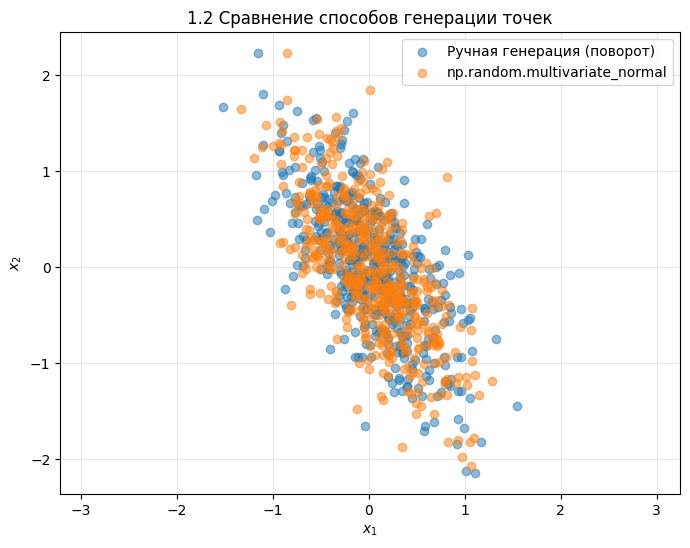

In [56]:
# Сравнение со встроенной функцией
# Генерация точек встроенной функцией
X_builtin = np.random.multivariate_normal(mean=[0, 0], cov=C_teor, size=M)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Ручная генерация (поворот)', color='tab:blue')
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], alpha=0.5, label='np.random.multivariate_normal', color='tab:orange')

plt.title("1.2 Сравнение способов генерации точек")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Облака визуально совпадают ( тот же центр, разброс и угол наклона).   Встроенная функциия может быть предподчтительнее засчет простоты генерации и легкой работы с большим количеством признаков.

##Часть 2. Визуализация плотности вероятности

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Оценка выборочных параметров mu_hat и C_hat ---
mu_hat = np.mean(X, axis=0)      # Выборочное среднее (вектор длины 2)
C_hat = np.cov(X.T)              # Выборочная ковариация (матрица 2x2)

In [58]:
# Создание сетки точек от -2 до 2
x_grid = np.linspace(-2, 2, 200)
y_grid = np.linspace(-2, 2, 200)
XX, YY = np.meshgrid(x_grid, y_grid)

# Упаковываем XX и YY в массив точек размерности (200, 200, 2)
pos = np.dstack((XX, YY))

In [59]:
# Вычисление плотности двумя способами

# Способ А: с помощью scipy.stats.multivariate_normal
rv = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = rv.pdf(pos)

# Способ Б: Самостоятельно по формуле многомерного нормального распределения
det_C = np.linalg.det(C_hat)
inv_C = np.linalg.inv(C_hat)

# Нормировочный коэффициент
norm_const = 1.0 / (2.0 * np.pi * np.sqrt(det_C))

# Квадратичная форма
DX = XX - mu_hat[0]
DY = YY - mu_hat[1]

Q = (DX**2 * inv_C[0, 0] +
     2 * DX * DY * inv_C[0, 1] +
     DY**2 * inv_C[1, 1])

pdf_manual = norm_const * np.exp(-0.5 * Q)

In [60]:
# Проверка ручного вычисления
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print(f"Максимальное расхождение: {max_diff:.2e}")

assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
print("Автопроверка пройдена")

Максимальное расхождение: 2.78e-16
Автопроверка пройдена


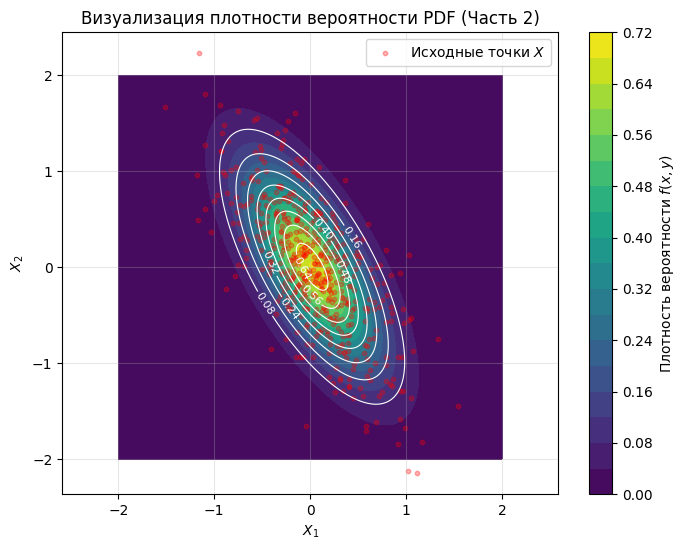

In [61]:
# Визуализация
plt.figure(figsize=(8, 6))

# 1. Заливка плотности (contourf)
cf = plt.contourf(XX, YY, pdf_scipy, levels=20)
plt.colorbar(cf, label='Плотность вероятности $f(x, y)$')

# 2. Линии уровня (contour) поверх заливки
contour_lines = plt.contour(XX, YY, pdf_scipy, levels=10, colors='white', linewidths=0.8)
plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.2f')

# 3. Исходные точки поверх фона
plt.scatter(X[:, 0], X[:, 1], c='red', alpha=0.3, s=10, label='Исходные точки $X$')

# Оформление
plt.axis('equal')
plt.title('Визуализация плотности вероятности PDF (Часть 2)')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Часть 3. Бинарная классификация через байесовский подход

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Генерация датасета

N0 = 300
N1 = 300
N_total = N0 + N1

# Параметры Класса 0
mu0 = np.array([-0.5, 0.5])
C0 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

# Параметры Класса 1
mu1 = np.array([0.5, -0.5])
C1 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

# Генерация выборок (точек)
X0 = np.random.multivariate_normal(mu0, C0, size=N0)
X1 = np.random.multivariate_normal(mu1, C1, size=N1)

# Априорные вероятности классов p(y) — доли объектов в выборке
p_y0 = N0 / N_total
p_y1 = N1 / N_total

In [63]:
# Вычисление Delta(x) над сеткой

# Сетка точек
x_grid = np.linspace(-2.5, 2.5, 200)
y_grid = np.linspace(-2.5, 2.5, 200)
XX, YY = np.meshgrid(x_grid, y_grid)
pos = np.dstack((XX, YY))

# Правдоподобия p(x|y=0) и p(x|y=1)
pdf_class0 = multivariate_normal(mean=mu0, cov=C0).pdf(pos)
pdf_class1 = multivariate_normal(mean=mu1, cov=C1).pdf(pos)

# Дискриминантная функция Delta(x) = p(x|y=0)*p(y=0) - p(x|y=1)*p(y=1)
Delta = pdf_class0 * p_y0 - pdf_class1 * p_y1

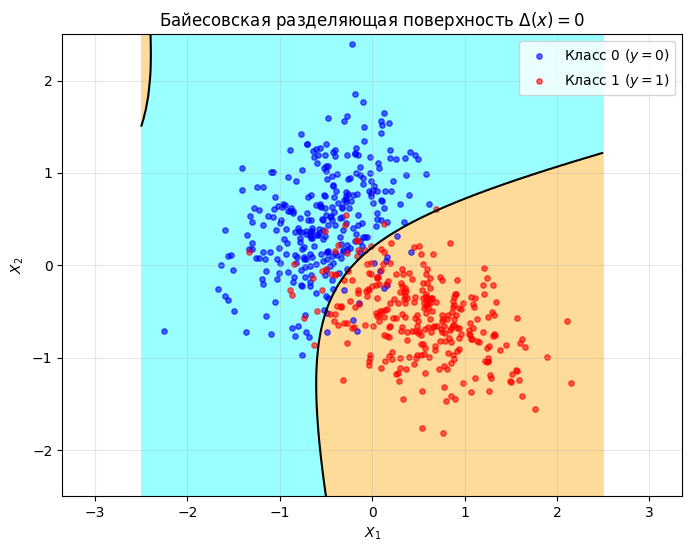

In [64]:
#  Визуализация
plt.figure(figsize=(8, 6))

# 1. Заливка фона: синий (Delta > 0), красный (Delta < 0)
plt.contourf(XX, YY, Delta, levels=[-np.inf, 0, np.inf], colors=['orange', 'cyan'], alpha=0.4)

# 2. Разделяющая поверхность: Delta(x) = 0
boundary = plt.contour(XX, YY, Delta, levels=[0], colors='black')

# 3. Scatter plot точек классов
plt.scatter(X0[:, 0], X0[:, 1], c='blue', alpha=0.6, s=15, label='Класс 0 ($y=0$)')
plt.scatter(X1[:, 0], X1[:, 1], c='red', alpha=0.6, s=15, label='Класс 1 ($y=1$)')

# Оформление
plt.axis('equal')
plt.title('Байесовская разделяющая поверхность $\\Delta(x) = 0$')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Разделяющая поверхность не является линейной. Она является кривой второго порядка, в данном случае гиперболой. Уравнение границы содержит квадратичную форму относительно $x$: $$-\frac{1}{2} x^T \left( C_0^{-1} - C_1^{-1} \right) x + w^T x + b = 0$$

## Часть 4. Линейный дискриминантный анализ (LDA)

In [65]:
import numpy as np
from sklearn.base import BaseEstimator



class MyLDA(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None  # словарь {class: mean_vector}
        self.priors_ = None  # словарь {class: prior_prob}
        self.cov_ = None  # общая ковариационная матрица (2D массив)
        self.coef_ = None  # вектор весов w
        self.intercept_ = None  # порог b

    def fit(self, X, y):
        """X: np.array, shape (n_samples, n_features)

        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        # 2. Для каждого класса: вычислить mean и prior
        self.means_ = {}
        self.priors_ = {}
        cov_list = []

        total_cov = np.zeros((n_features, n_features))

        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c, axis=0)
            self.priors_[c] = len(X_c) / n_samples
            cov_c = np.cov(X_c.T)
            total_cov += (len(X_c) - 1) * cov_c
            cov_list.append(cov_c)

        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        self.cov_ = total_cov / (n_samples - len(self.classes_))

        # Добавление регуляризатора для устойчивости
        cov_reg = self.cov_ + 1e-6 * np.eye(n_features)
        inv_C = np.linalg.inv(cov_reg)

        # 4. Вычислить w и b
        mu0 = self.means_[self.classes_[0]]
        mu1 = self.means_[self.classes_[1]]
        p0 = self.priors_[self.classes_[0]]
        p1 = self.priors_[self.classes_[1]]

        self.coef_ = inv_C @ (mu1 - mu0)
        self.intercept_ = (
            -0.5 * mu1.T @ inv_C @ mu1
            + 0.5 * mu0.T @ inv_C @ mu0
            + np.log(p1 / p0)
        )

        return self

    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        # Линейная дискриминантная функция d(x) = w^T x + b
        d = X @ self.coef_ + self.intercept_

        # Сигмоида для вычисления вероятностей
        p1 = 1.0 / (1.0 + np.exp(-d))
        p0 = 1.0 - p1

        return np.column_stack([p0, p1])

    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        probs = self.predict_proba(X)
        indices = np.argmax(probs, axis=1)
        return self.classes_[indices]


In [66]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

# Создание двух классов с одинаковой ковариацией C и разными средними
np.random.seed(42)

N0, N1 = 300, 300
mu0 = np.array([-1.5, -1.0])
mu1 = np.array([1.5, 1.0])
C = np.array([[1.0, 0.5], [0.5, 1.0]])

X0 = np.random.multivariate_normal(mu0, C, size=N0)
X1 = np.random.multivariate_normal(mu1, C, size=N1)

X = np.vstack([X0, X1])
y = np.array([0] * N0 + [1] * N1)

# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [67]:
# Обучение моделей и автопроверка
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)

# Автопроверка
# Сравнение с sklearn
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.max(np.abs(my_lda.coef_ / sk_lda.coef_ - 1)) < 1e-5, "Вектора весов сонаправлены, но разной длины" #Строка исправлена (из-за требуемого регуляризатора) с np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6
print("Автопроверка пройдена")

Автопроверка пройдена


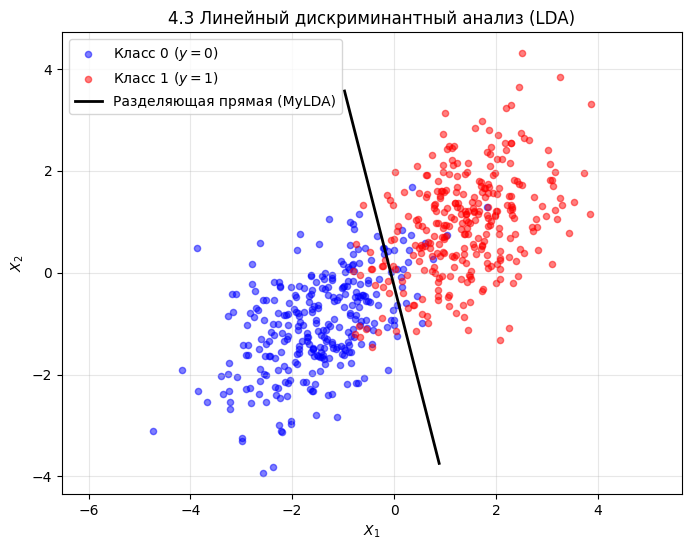

In [68]:
# Визуализация разделяющей прямой и точек
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    X0[:, 0], X0[:, 1], color="blue", alpha=0.5, s=20, label="Класс 0 ($y=0$)"
)
plt.scatter(
    X1[:, 0], X1[:, 1], color="red", alpha=0.5, s=20, label="Класс 1 ($y=1$)"
)

# Построение разделяющей прямой w0*x1 + w1*x2 + b = 0  =>  x2 = -(w0*x1 + b) / w1
x1_vals = np.linspace(X[:, 0].min()*0.1 - 0.5, X[:, 0].max()*0.1 + 0.5, 200)
w = my_lda.coef_
b = my_lda.intercept_
x2_vals = -(w[0] * x1_vals + b) / w[1]

plt.plot(
    x1_vals,
    x2_vals,
    color="black",
    linewidth=2,
    label="Разделяющая прямая (MyLDA)",
)

plt.title("4.3 Линейный дискриминантный анализ (LDA)")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Часть 5. Наивный байесовский классификатор (NB)

Матрица ковариации диагональна, потому что на ее внедиагональных элементах стоят ковариации признаков, а поскольку в наивном Байесе признаки считаются условно независимыми, их ковариация равна нулю.

Поскольку признаки независимы, вероятность одновременного наступления событий для классов равна произведению вероятностей каждого признака:

$$p(x|y) = \prod_{i=1}^{d} p(x_i|y)$$

In [69]:
import numpy as np
from sklearn.base import BaseEstimator


class MyNB(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None   # dict {class: mean_vector}
        self.vars_ = None    # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None  # dict {class: prior_prob}

    def fit(self, X, y):
        """Для каждого класса:

        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c, axis=0)
            self.vars_[c] = np.var(X_c, axis=0)
            self.priors_[c] = len(X_c) / n_samples

        return self

    def predict_joint_log_likelihood(self, X):
        """Вычисляет совместное логарифмическое правдоподобие log p(y) + log p(X|y)

        по формуле: log p(y) - 0.5 * sum_i ( log(2 * pi * sigma_{y,i}^2) + (x_i - mu_{y,i})^2 / sigma_{y,i}^2 )
        """
        n_samples, n_features = X.shape
        joint_log_likelihood = []

        for c in self.classes_:
            mean = self.means_[c]
            var = self.vars_[c]
            prior = self.priors_[c]

            # Вычисление логарифма априорной вероятности
            log_prior = np.log(prior)

            # Вычисление суммы логарифмов одномерных плотностей по всем признакам (axis=1)
            log_pdf = -0.5 * np.sum(
                np.log(2.0 * np.pi * var) + ((X - mean) ** 2) / var,
                axis=1
            )

            joint_log_likelihood.append(log_prior + log_pdf)

        # Возвращает массив формы (n_samples, n_classes)
        return np.column_stack(joint_log_likelihood)

    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        jll = self.predict_joint_log_likelihood(X)
        indices = np.argmax(jll, axis=1)
        return self.classes_[indices]

In [70]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# 1. Подготовка синтетических данных
N0, N1 = 300, 300
mu0, mu1 = np.array([-1.5, -1.0]), np.array([1.5, 1.0])
C = np.array([[1.0, 0.5], [0.5, 1.0]])

X0 = np.random.multivariate_normal(mu0, C, size=N0)
X1 = np.random.multivariate_normal(mu1, C, size=N1)
X = np.vstack([X0, X1])
y = np.array([0] * N0 + [1] * N1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

# Автопроверка
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"

print("Автопроверка успешно пройдена.")

Автопроверка успешно пройдена.


## Часть 6. Экспериментальное сравнение LDA и NB

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)

N_samples = 1000
n_features = 10

# -------------------------------------------------------------------------
# 1. Датасет A (LDA-оптимальный): общая недиагональная ковариация
# -------------------------------------------------------------------------
mean0_A = np.zeros(n_features)
mean1_A = np.ones(n_features) * 1.5

# Генерируем случайную ковариационную матрицу
A_mat = A = np.random.uniform(-1, 1, size=(n_features, n_features))
cov_A = A_mat @ A_mat.T + np.eye(n_features)

X0_A = np.random.multivariate_normal(mean0_A, cov_A, size=N_samples // 2)
X1_A = np.random.multivariate_normal(mean1_A, cov_A, size=N_samples // 2)
X_A = np.vstack([X0_A, X1_A])
y_A = np.array([0] * (N_samples // 2) + [1] * (N_samples // 2))

# -------------------------------------------------------------------------
# 2. Датасет B (NB-оптимальный): независимые признаки
# -------------------------------------------------------------------------
cov0_B = np.diag(np.random.uniform(0.5, 2.5, size=n_features))
cov1_B = np.diag(np.random.uniform(0.5, 2.5, size=n_features))
mean0_B = np.zeros(n_features)
mean1_B = np.ones(n_features) * 1.5

X0_B = np.random.multivariate_normal(mean0_B, cov0_B, size=N_samples // 2)
X1_B = np.random.multivariate_normal(mean1_B, cov1_B, size=N_samples // 2)
X_B = np.vstack([X0_B, X1_B])
y_B = np.array([0] * (N_samples // 2) + [1] * (N_samples // 2))

# -------------------------------------------------------------------------
# 3. Датасет C (Сложный)
# -------------------------------------------------------------------------
X_C, y_C = make_classification(
    n_samples=N_samples,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    flip_y=0.05,
)

datasets = {
    "Датасет A (LDA-оптимальный)": (X_A, y_A),
    "Датасет B (NB-оптимальный)": (X_B, y_B),
    "Датасет C (Сложный)": (X_C, y_C)
}

In [74]:
# Функция для вычисления метрик и оценки трех моделей
def evaluate_all_datasets(datasets):
    all_results = []
    confusion_matrices = {}

    for ds_name, (X, y) in datasets.items():
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y
        )

        models = {
            "MyLDA": MyLDA(),
            "MyNB": MyNB(),
            "LogisticRegression": LogisticRegression()
        }

        confusion_matrices[ds_name] = {}

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
            p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
            cm = confusion_matrix(y_test, y_pred)

            confusion_matrices[ds_name][model_name] = cm

            all_results.append({
                "Dataset": ds_name,
                "Model": model_name,
                "Accuracy": acc,
                "Precision (Class 0)": p_cls[0],
                "Precision (Class 1)": p_cls[1],
                "Recall (Class 0)": r_cls[0],
                "Recall (Class 1)": r_cls[1],
                "F1 (Class 0)": f1_cls[0],
                "F1 (Class 1)": f1_cls[1],
                "Precision (Macro)": p_mac,
                "Recall (Macro)": r_mac,
                "F1 (Macro)": f1_mac
            })

    return pd.DataFrame(all_results), confusion_matrices

df_results, cm_dict = evaluate_all_datasets(datasets)

# Отображение таблицы с основными метриками
df_summary = df_results[["Dataset", "Model", "Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 (Macro)"]]
print(df_summary.to_string(index=False))

                    Dataset              Model  Accuracy  Precision (Macro)  Recall (Macro)  F1 (Macro)
Датасет A (LDA-оптимальный)              MyLDA     0.940           0.940705        0.940000    0.939976
Датасет A (LDA-оптимальный)               MyNB     0.920           0.920673        0.920000    0.919968
Датасет A (LDA-оптимальный) LogisticRegression     0.920           0.921517        0.920000    0.919928
 Датасет B (NB-оптимальный)              MyLDA     0.970           0.970188        0.970000    0.969997
 Датасет B (NB-оптимальный)               MyNB     0.975           0.975048        0.975000    0.974999
 Датасет B (NB-оптимальный) LogisticRegression     0.960           0.961662        0.960000    0.959964
        Датасет C (Сложный)              MyLDA     0.810           0.811028        0.810281    0.809924
        Датасет C (Сложный)               MyNB     0.800           0.801829        0.800380    0.799820
        Датасет C (Сложный) LogisticRegression     0.815        

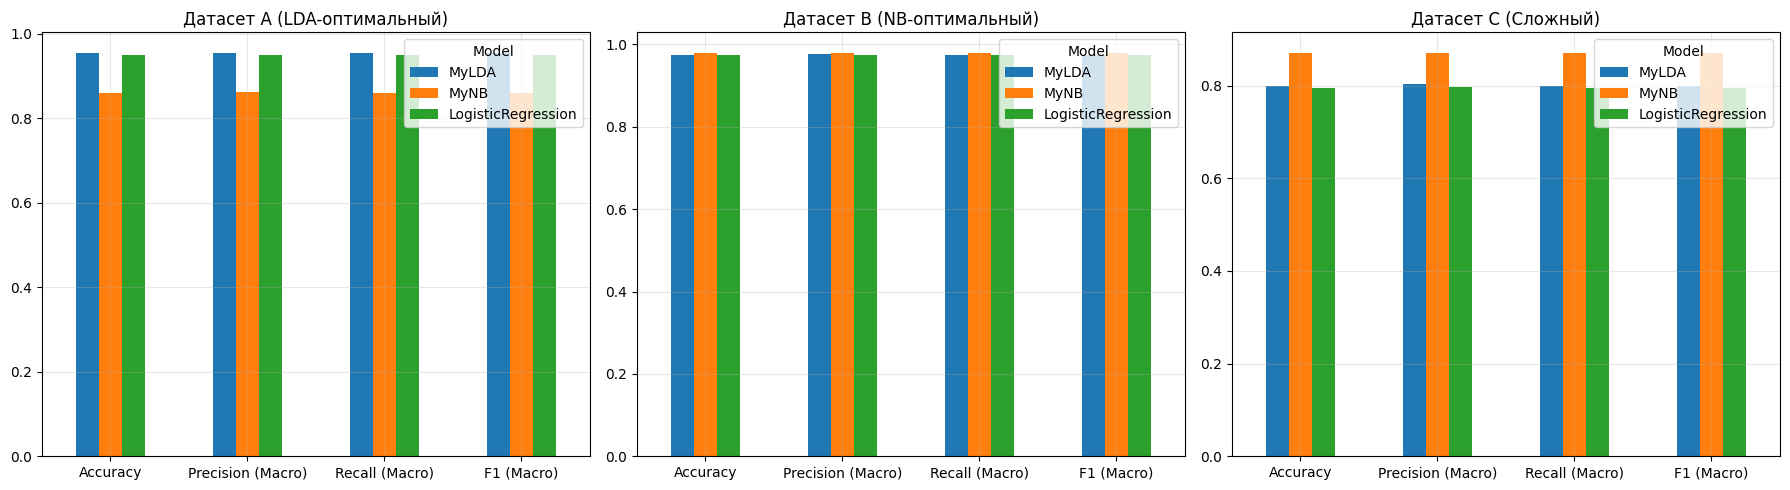

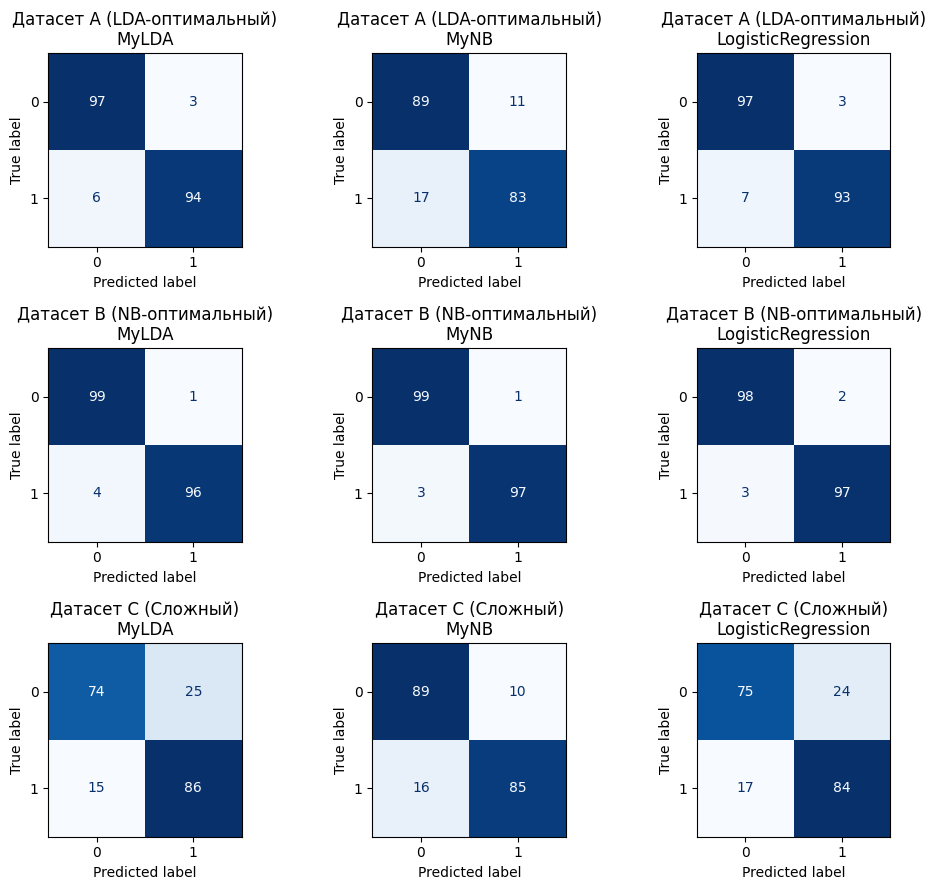

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Сравнительные столбчатые диаграммы метрик
metrics_to_plot = ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 (Macro)"]
dataset_names = list(datasets.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ds_name in enumerate(dataset_names):
    # 1. Фильтруем данные по датасету и делаем колонку "Model" индексом
    df_ds = df_results[df_results["Dataset"] == ds_name].set_index("Model")[metrics_to_plot]

    # 2. .T транспонирует таблицу: метрики идут на ось X, а модели становятся цветами столбцов
    df_ds.T.plot(kind="bar", ax=axes[i], rot=0)

    # 3. Настройка внешнего вида
    axes[i].set_title(ds_name)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 2. Отрисовка Confusion Matrix

models_list = ["MyLDA", "MyNB", "LogisticRegression"]
fig, axes = plt.subplots(3, 3, figsize=(10, 9))

for r, ds_name in enumerate(dataset_names):
    for c, model_name in enumerate(models_list):
        cm = cm_dict[ds_name][model_name]

        # Отрисовка матрицы ошибок
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(ax=axes[r, c], cmap="Blues", colorbar=False)

        axes[r, c].set_title(f"{ds_name}\n{model_name}")

plt.tight_layout()
plt.show()



#### 1. На каком датасете LDA превосходит NB? Почему?
Ответ: На датасете A.

 Датасет A сформирован так, что ковариационные матрицы классов совпадают ($C_0 = C_1$), но признаки содержат корреляции. Это соответствует допущению дискриминантного анализа (LDA), поэтому истинная разделяющая поверхность является строго линейной.

#### 2. На каком датасете NB работает лучше? Почему?
Ответ: На датасете B.

 В датасете B признаки условно независимы внутри каждого класса , что соответствует допущению наивного Байеса. При этом ковариации классов различаются ($C_0 \neq C_1$), из-за чего истинная граница раздела квадратична. LDA усредняет ковариационные матрицы и проводит линейную границу.

#### 3. Как влияет размерность пространства на обе модели?

При увеличении размерности пространства ($d$) линейный дискриминантный анализ пытаются оценить ковариационную матрицу, состоящую из $(d^2)$ элементов, в то время как наивный байес пытается вычислить только $d$ элементов (диагональ).

Если данных мало ($N$), а размерность пространства большая ($d$), то:

Линейный дискриминантный анализ (LDA) быстро теряет качество для $O(d^2)$ параметров не хватает данных, из-за чего выборочная ковариационная матрица получается плохо обусловленной. При её обращении даже небольшой случайный шум усиливается, и LDA начинает переобучаться.

Наивный Байес (NB) устойчивее: оценивая всего $d$ независимых параметров, модель имеет низкую дисперсию оценки, несмотря на ошибку из-за проигнорированных корреляций.

#### 4. Когда обе модели падают (датасет C) — почему?
Метрики качества двух моделей падают датасете C из-за одновременного нарушения допущений каждого из методов: ковариационные матрицы классов не равны, из-за чего истинная разделяющая граница является нелинейной а также признаки коррелированы между собой. Также в датасете C есть шум.